# Limits — A Game of Closeness

I always thought the epsilon-delta definition of limits was just letters moving around on a page. Then I realised it's not a math problem at all — it's a **precision problem**. The algebra is just the translation layer.

Here's what finally made it click for me.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

## Step 1 — The Naive Approach: Just Solve the Inequality

Let me start with how I *first* tried to understand limits, because I think this is where most people start.

Say we have $f(x) = 2x - 1$ and we want to show $\lim_{x \to 3} f(x) = 5$.

Someone tells me: "keep the output within $0.1$ of $5$." So I write:

$$2x - 6 < 0.1$$

Add $6$ to both sides: $2x < 6.1$

Divide by $2$: $x < 3.05$

Done, right?

**Not quite.** I only found the ceiling. I only checked that $x$ doesn't go too far *right*. But what about going too far *left*? If $x = 2.0$, then $f(x) = 3$, which is way below $5$. My one-sided inequality didn't catch that.

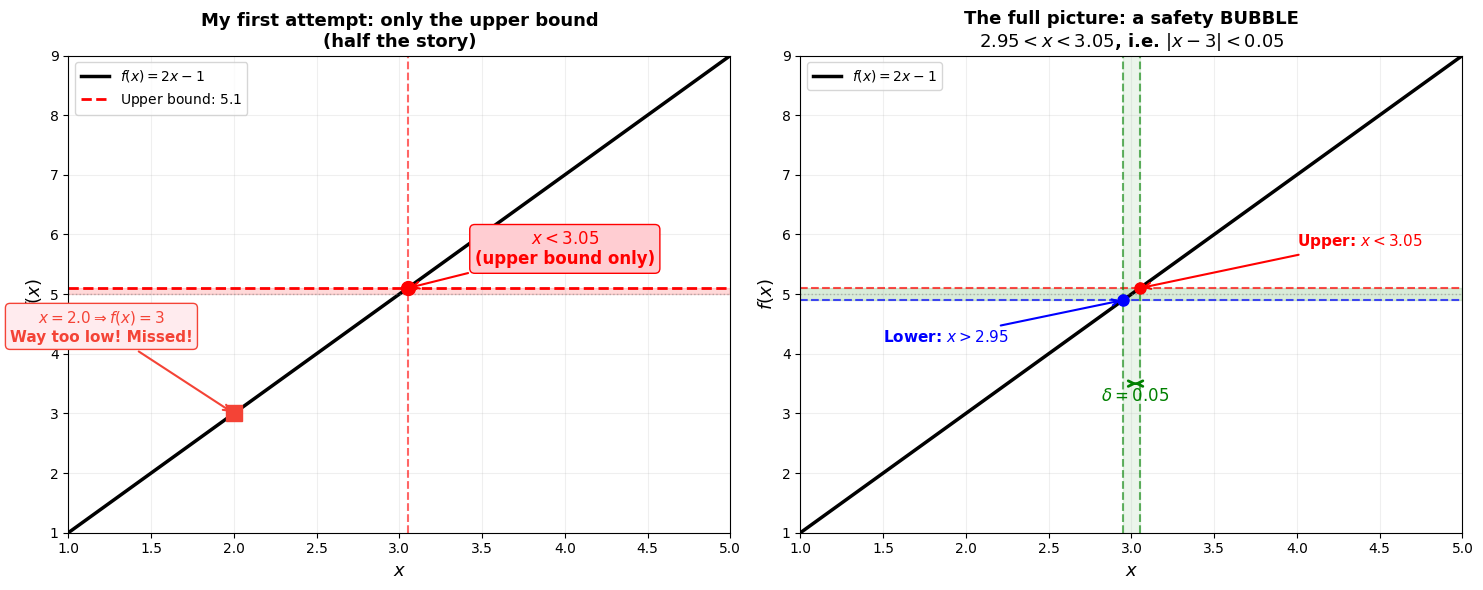

In [3]:
# === DIAGRAM 1: The naive one-sided approach — what it misses ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x = np.linspace(1, 5, 200)
f = 2 * x - 1

# --- LEFT: The one-sided view ---
ax1.plot(x, f, 'k-', lw=2.5, label='$f(x) = 2x - 1$')
ax1.axhline(5, color='gray', ls=':', lw=1, alpha=0.5)
ax1.axhline(5.1, color='red', ls='--', lw=2, label='Upper bound: $5.1$')
ax1.axvline(3.05, color='red', ls='--', lw=1.5, alpha=0.6)

# Shade the "safe" region (only above)
ax1.fill_between(x, 5, 5.1, alpha=0.15, color='red')

# Mark the ceiling
ax1.plot(3.05, 5.1, 'ro', ms=10, zorder=5)
ax1.annotate('$x < 3.05$\n(upper bound only)',
             xy=(3.05, 5.1), xytext=(4, 5.5),
             fontsize=12, ha='center', fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             bbox=dict(fc='#FFCDD2', ec='red', boxstyle='round,pad=0.3'))

# Show the problem: x = 2.0 gives f(x) = 3, way off!
ax1.plot(2.0, 3.0, 's', color='#F44336', ms=12, zorder=5)
ax1.annotate('$x = 2.0 \\Rightarrow f(x) = 3$\nWay too low! Missed!',
             xy=(2.0, 3.0), xytext=(1.2, 4.2),
             fontsize=11, ha='center', fontweight='bold', color='#F44336',
             arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5),
             bbox=dict(fc='#FFEBEE', ec='#F44336', boxstyle='round,pad=0.3'))

ax1.set_xlabel('$x$', fontsize=13)
ax1.set_ylabel('$f(x)$', fontsize=13)
ax1.set_title('My first attempt: only the upper bound\n(half the story)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)
ax1.set_xlim(1, 5)
ax1.set_ylim(1, 9)

# --- RIGHT: Both bounds ---
ax2.plot(x, f, 'k-', lw=2.5, label='$f(x) = 2x - 1$')
ax2.axhline(5, color='gray', ls=':', lw=1, alpha=0.5)
ax2.axhline(5.1, color='red', ls='--', lw=1.5, alpha=0.7)
ax2.axhline(4.9, color='blue', ls='--', lw=1.5, alpha=0.7)

# Shade the full safety band on y
ax2.fill_between(x, 4.9, 5.1, alpha=0.15, color='green')

# Shade the corresponding x band
ax2.axvline(2.95, color='green', ls='--', lw=1.5, alpha=0.6)
ax2.axvline(3.05, color='green', ls='--', lw=1.5, alpha=0.6)
ax2.fill_betweenx([0, 10], 2.95, 3.05, alpha=0.08, color='green')

# Mark both bounds
ax2.plot(3.05, 5.1, 'ro', ms=8, zorder=5)
ax2.plot(2.95, 4.9, 'bo', ms=8, zorder=5)

ax2.annotate('Upper: $x < 3.05$',
             xy=(3.05, 5.1), xytext=(4, 5.8),
             fontsize=11, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax2.annotate('Lower: $x > 2.95$',
             xy=(2.95, 4.9), xytext=(1.5, 4.2),
             fontsize=11, color='blue', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

# The δ annotation
ax2.annotate('', xy=(3.05, 3.5), xytext=(3.0, 3.5),
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax2.text(3.025, 3.2, '$\\delta = 0.05$', fontsize=12, ha='center',
         color='green', fontweight='bold')

ax2.set_xlabel('$x$', fontsize=13)
ax2.set_ylabel('$f(x)$', fontsize=13)
ax2.set_title('The full picture: a safety BUBBLE\n$2.95 < x < 3.05$, i.e. $|x - 3| < 0.05$',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.set_xlim(1, 5)
ax2.set_ylim(1, 9)

plt.tight_layout()
plt.show()

## Step 2 — It's a Bubble, Not a Ceiling

That one-sided calculation was only half the story. The limit isn't saying "don't go too high" — it's saying "**stay close**."

So I actually need **two** inequalities:

**Upper bound:** $2x - 1 < 5.1$ → $x < 3.05$

**Lower bound:** $2x - 1 > 4.9$ → $x > 2.95$

Combined: $2.95 < x < 3.05$

The distance from the centre ($3$) to either edge ($2.95$ or $3.05$) is exactly $0.05$. That's why we wrap it in absolute values:

$$|x - 3| < 0.05$$

This creates a **symmetric safety zone** — a bubble around $x = 3$. Stay inside the bubble, and the output is guaranteed to stay within $0.1$ of $5$.

Think of it like a speed limit with a tolerance. If the sign says "stay within $0.1$ of 5 mph," I'm not just worried about going too fast ($5.1$) — I'm also checking I'm not going too slow ($4.9$). The bubble catches both sides.

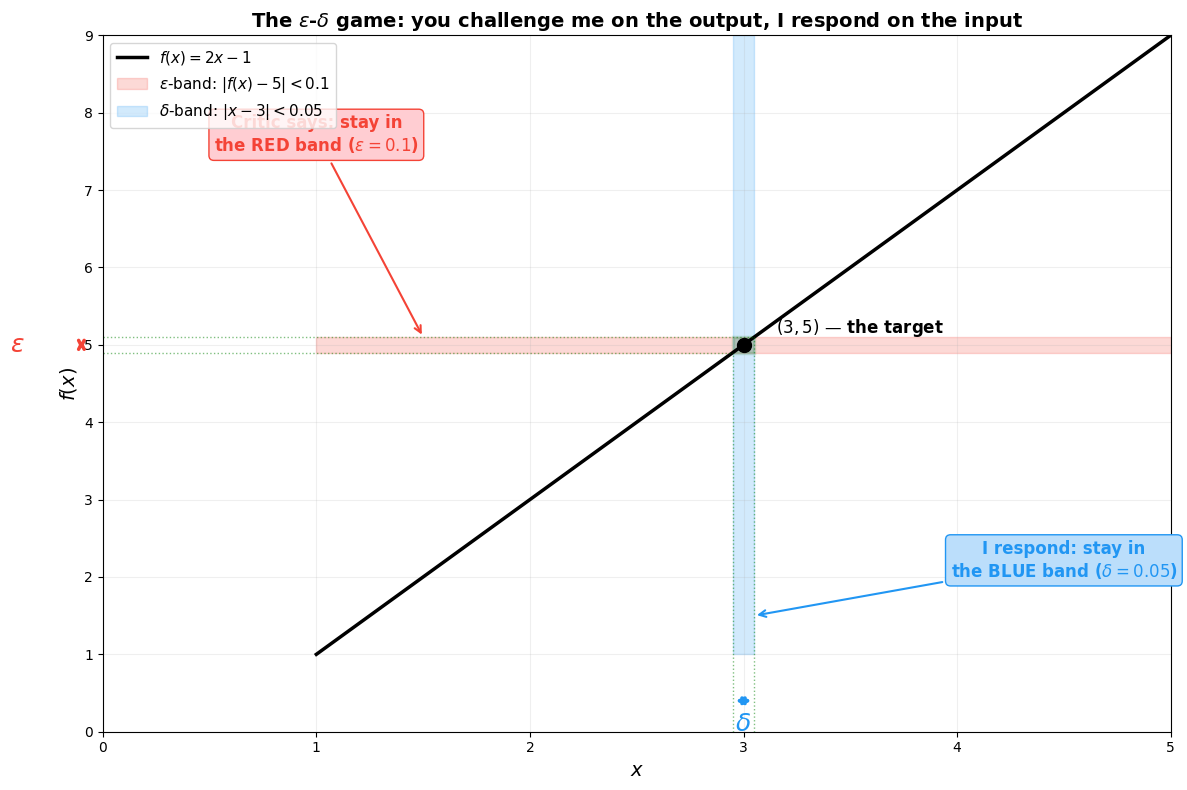

In [5]:
# === DIAGRAM 2: The bubble visualisation — input bubble maps to output bubble ===

fig, ax = plt.subplots(figsize=(12, 8))

x = np.linspace(1, 5, 300)
f = 2 * x - 1

# The function
ax.plot(x, f, 'k-', lw=2.5, label='$f(x) = 2x - 1$')

# Target point
ax.plot(3, 5, 'ko', ms=10, zorder=5)
ax.text(3.15, 5.15, '$(3, 5)$ — the target', fontsize=12, fontweight='bold')

# Epsilon band on y-axis (the challenge)
eps = 0.1
ax.fill_between(x, 5 - eps, 5 + eps, alpha=0.2, color='#F44336',
                label=f'$\\epsilon$-band: $|f(x) - 5| < {eps}$')
ax.annotate('', xy=(-0.1, 5 + eps), xytext=(-0.1, 5 - eps),
            arrowprops=dict(arrowstyle='<->', color='#F44336', lw=2.5),
            annotation_clip=False)
ax.text(-0.4, 5, '$\\epsilon$', fontsize=18, ha='center', va='center',
        color='#F44336', fontweight='bold')

# Delta band on x-axis (the response)
delta = 0.05
ax.fill_betweenx(f, 3 - delta, 3 + delta, alpha=0.2, color='#2196F3',
                  label=f'$\\delta$-band: $|x - 3| < {delta}$')
ax.annotate('', xy=(3 + delta, 0.4), xytext=(3 - delta, 0.4),
            arrowprops=dict(arrowstyle='<->', color='#2196F3', lw=2.5))
ax.text(3, 0.1, '$\\delta$', fontsize=18, ha='center', va='center',
        color='#2196F3', fontweight='bold')

# Show the mapping: delta box → epsilon box
# Draw the "box" formed by the intersection
rect = patches.Rectangle((3 - delta, 5 - eps), 2 * delta, 2 * eps,
                          lw=2.5, ec='green', fc='green', alpha=0.15)
ax.add_patch(rect)

# The line passes through this box
ax.plot([3 - delta, 3 - delta], [0, 5 - eps], 'g:', lw=1, alpha=0.5)
ax.plot([3 + delta, 3 + delta], [0, 5 + eps], 'g:', lw=1, alpha=0.5)
ax.plot([0, 3 - delta], [5 - eps, 5 - eps], 'g:', lw=1, alpha=0.5)
ax.plot([0, 3 + delta], [5 + eps, 5 + eps], 'g:', lw=1, alpha=0.5)

# Arrow showing the logic
ax.annotate('Critic says: stay in\nthe RED band ($\\epsilon = 0.1$)',
            xy=(1.5, 5.1), xytext=(1.0, 7.5),
            fontsize=12, ha='center', color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5),
            bbox=dict(fc='#FFCDD2', ec='#F44336', boxstyle='round,pad=0.3'))

ax.annotate('I respond: stay in\nthe BLUE band ($\\delta = 0.05$)',
            xy=(3.05, 1.5), xytext=(4.5, 2),
            fontsize=12, ha='center', color='#2196F3', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5),
            bbox=dict(fc='#BBDEFB', ec='#2196F3', boxstyle='round,pad=0.3'))

ax.set_xlabel('$x$', fontsize=14)
ax.set_ylabel('$f(x)$', fontsize=14)
ax.set_title('The $\\epsilon$-$\\delta$ game: you challenge me on the output, '
             'I respond on the input',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(0, 5)
ax.set_ylim(0, 9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Step 3 — The Challenge-and-Response Game

Here's the way I think about $\epsilon$-$\delta$ that actually makes sense.

Imagine I'm operating a laser. My hand is on a dial (the $x$-axis), and the laser hits a wall (the $y$-axis). A critic watches and we play a game:

**Round 1:** Critic says "I need the laser within $0.1$ of the centre." ($\epsilon = 0.1$)
I calculate: "Okay, my hand can't wobble more than $0.05$." ($\delta = 0.05$)

**Round 2:** Critic tightens it: "Within $0.01$ now." ($\epsilon = 0.01$)
I calculate: "Fine, hand wobble under $0.005$." ($\delta = 0.005$)

**Round 3:** Critic goes extreme: "Within $0.0001$." ($\epsilon = 0.0001$)
I calculate: "$\delta = 0.00005$." Still fine.

The limit **exists** if I can **always** find a response, no matter how tight the critic gets. If there's some $\epsilon$ where I'm stuck and can't find any $\delta$ that works, the limit doesn't exist at that point.

For $f(x) = 2x - 1$, my response is always $\delta = \epsilon / 2$. The slope is $2$, so the output moves **twice as fast** as the input. To be accurate on the $y$-axis, I have to be **twice as steady** on the $x$-axis.

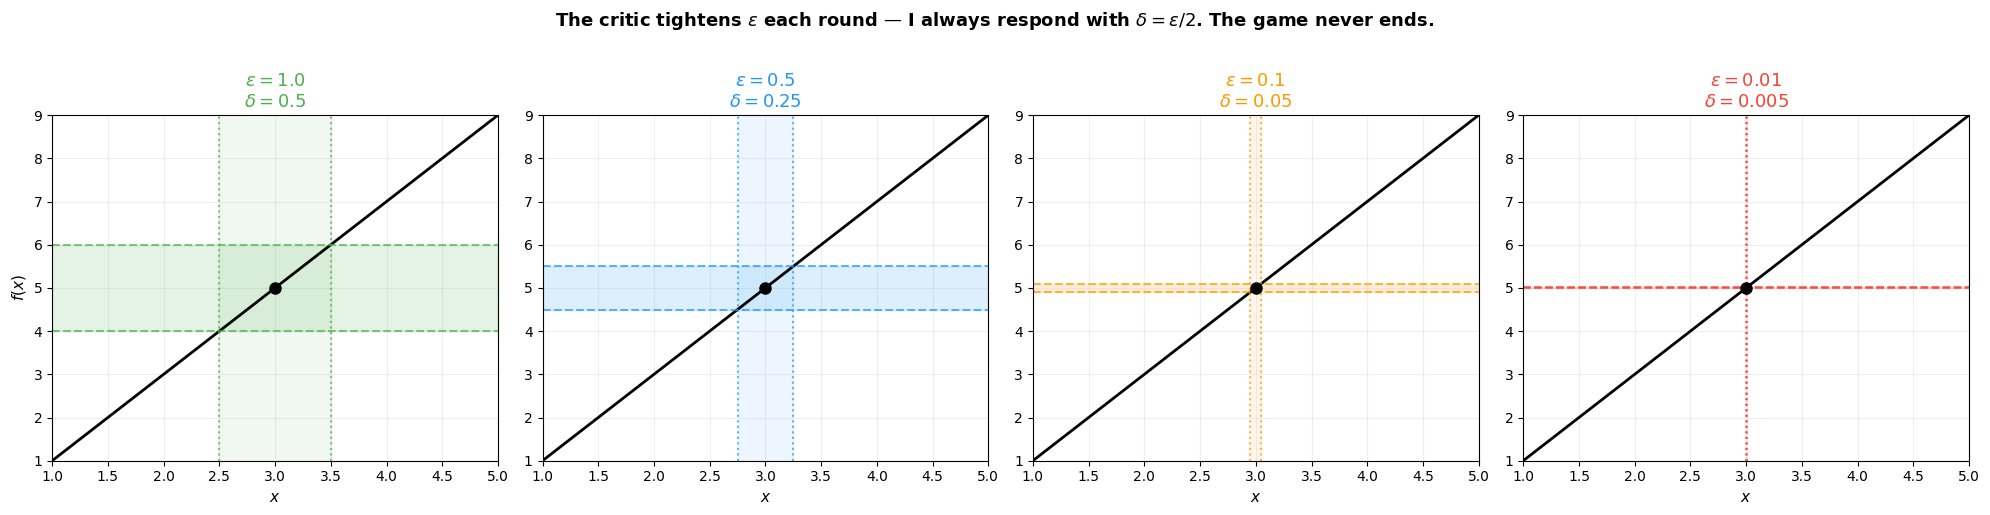

In [6]:
# === DIAGRAM 3: Multiple rounds of the game — tighter and tighter ===

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

x = np.linspace(1, 5, 300)
f_vals = 2 * x - 1

epsilons = [1.0, 0.5, 0.1, 0.01]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

for ax, eps, col in zip(axes, epsilons, colors):
    delta = eps / 2  # because slope = 2
    
    ax.plot(x, f_vals, 'k-', lw=2)
    ax.plot(3, 5, 'ko', ms=8, zorder=5)
    
    # Epsilon band
    ax.axhline(5 + eps, color=col, ls='--', lw=1.5, alpha=0.7)
    ax.axhline(5 - eps, color=col, ls='--', lw=1.5, alpha=0.7)
    ax.fill_between(x, 5 - eps, 5 + eps, alpha=0.15, color=col)
    
    # Delta band
    ax.axvline(3 + delta, color=col, ls=':', lw=1.5, alpha=0.7)
    ax.axvline(3 - delta, color=col, ls=':', lw=1.5, alpha=0.7)
    ax.fill_betweenx([0, 10], 3 - delta, 3 + delta, alpha=0.08, color=col)
    
    ax.set_title(f'$\\epsilon = {eps}$\n$\\delta = {delta}$',
                 fontsize=13, fontweight='bold', color=col)
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 9)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('$x$', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('$f(x)$', fontsize=11)

fig.suptitle('The critic tightens $\\epsilon$ each round — I always respond with $\\delta = \\epsilon / 2$. The game never ends.',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Translating Vertical to Horizontal: Where the Algebra Lives

The part that used to confuse me was *why* we do all this algebraic manipulation. Now I see it clearly:

**The critic gives me a vertical constraint** (on $y$): $|f(x) - L| < \epsilon$

**I need to translate that into a horizontal constraint** (on $x$): $|x - c| < \delta$

The algebra is just the **translation layer** between the two. I'm "undoing" the function to figure out what the input needs to be.

Let me walk through it step by step for $f(x) = 2x - 1$, limit at $x = 3$, target $L = 5$:

$$|f(x) - 5| < \epsilon$$
$$|(2x - 1) - 5| < \epsilon$$
$$|2x - 6| < \epsilon$$
$$|2(x - 3)| < \epsilon$$
$$2|x - 3| < \epsilon$$
$$|x - 3| < \frac{\epsilon}{2}$$

So $\delta = \frac{\epsilon}{2}$.

Notice what happened: the **slope** ($2$) came out of the absolute value. Because $f$ amplifies input changes by a factor of $2$, I need to be **twice as precise** on the input to hit the target. The slope is the "exchange rate" between input precision and output precision.

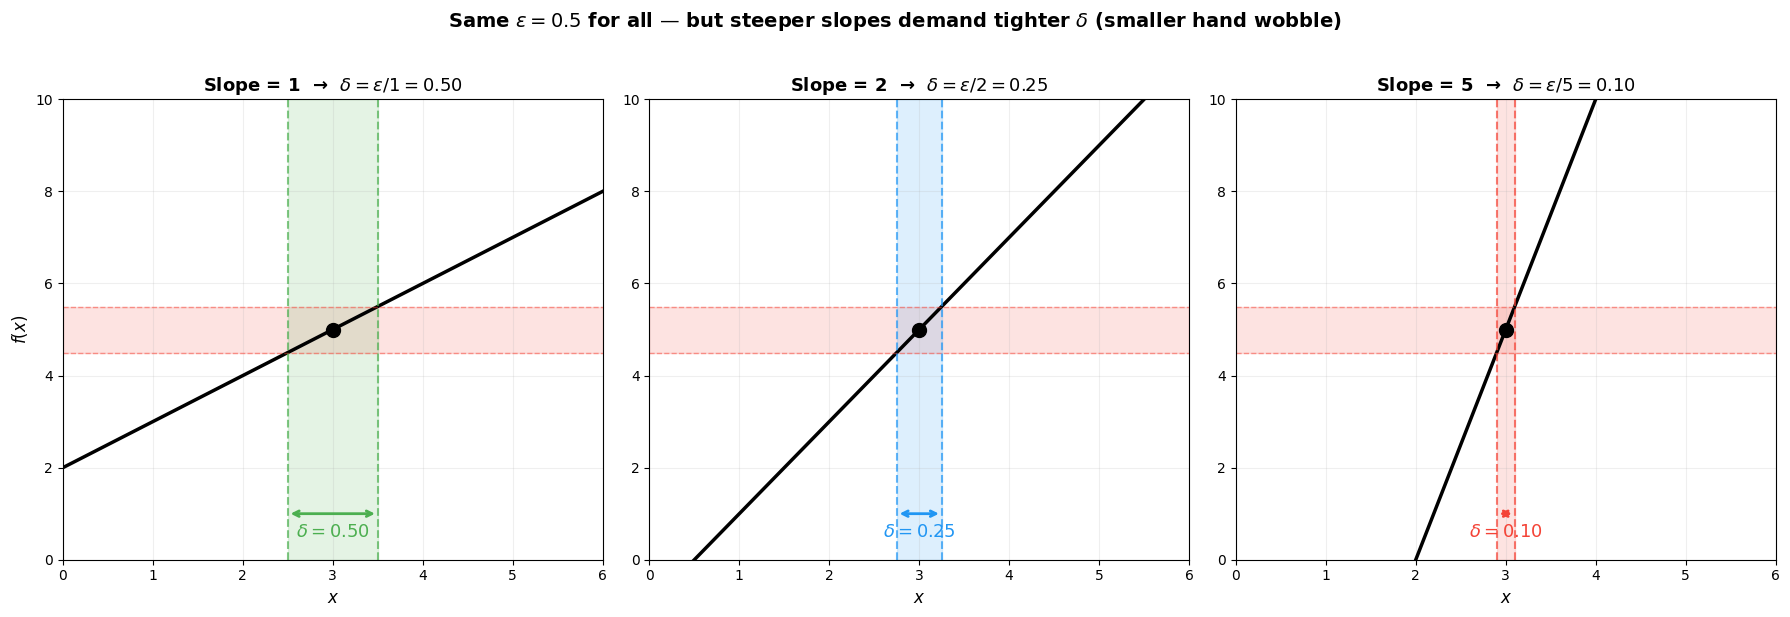

In [7]:
# === DIAGRAM 4: The slope as an "exchange rate" — steeper = more precision needed ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

slopes = [1, 2, 5]
colors = ['#4CAF50', '#2196F3', '#F44336']
eps = 0.5  # same epsilon for all

for ax, m, col in zip(axes, slopes, colors):
    x = np.linspace(0, 6, 200)
    # f(x) = m*(x - 3) + 5, so f(3) = 5, slope = m
    f_vals = m * (x - 3) + 5
    delta = eps / m
    
    ax.plot(x, f_vals, 'k-', lw=2.5)
    ax.plot(3, 5, 'ko', ms=10, zorder=5)
    
    # Epsilon band (same for all)
    ax.fill_between(x, 5 - eps, 5 + eps, alpha=0.15, color='#F44336')
    ax.axhline(5 + eps, color='#F44336', ls='--', lw=1, alpha=0.5)
    ax.axhline(5 - eps, color='#F44336', ls='--', lw=1, alpha=0.5)
    
    # Delta band (shrinks with steeper slope!)
    ax.fill_betweenx([0, 10], 3 - delta, 3 + delta, alpha=0.15, color=col)
    ax.axvline(3 + delta, color=col, ls='--', lw=1.5, alpha=0.7)
    ax.axvline(3 - delta, color=col, ls='--', lw=1.5, alpha=0.7)
    
    # Delta annotation
    ax.annotate('', xy=(3 + delta, 1), xytext=(3 - delta, 1),
                arrowprops=dict(arrowstyle='<->', color=col, lw=2))
    ax.text(3, 0.5, f'$\\delta = {delta:.2f}$', fontsize=13, ha='center',
            color=col, fontweight='bold')
    
    ax.set_title(f'Slope = {m}  →  $\\delta = \\epsilon / {m} = {delta:.2f}$',
                 fontsize=13, fontweight='bold')
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('$x$', fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel('$f(x)$', fontsize=12)

fig.suptitle('Same $\\epsilon = 0.5$ for all — but steeper slopes demand tighter $\\delta$ '
             '(smaller hand wobble)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5 — Why the Absolute Value Matters: The Bubble Must Be Symmetric

I want to come back to my original mistake because I think it's important.

When I wrote $2x - 6 < 0.1$ without absolute values, I was saying "the output can overshoot by $0.1$." But $|2x - 6| < 0.1$ says "the output can't deviate by more than $0.1$ **in either direction**."

The absolute value turns a one-sided ceiling into a two-sided bubble:

| Notation | What it says | What it means |
|:-:|:-:|:--|
| $2x - 6 < 0.1$ | Output below $5.1$ | Only the ceiling — I can still go way below |
| $\|2x - 6\| < 0.1$ | Output within $0.1$ of $5$ | The full bubble — both too-high and too-low are caught |

The limit definition says: for **every** $\epsilon > 0$, there exists a $\delta > 0$ such that

$$0 < |x - c| < \delta \implies |f(x) - L| < \epsilon$$

The $|x - c| < \delta$ part is my bubble on the input. The $|f(x) - L| < \epsilon$ part is the critic's bubble on the output. The function maps one bubble into the other.

In [ ]:
# === DIAGRAM 5: One-sided vs bubble — the difference is everything ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_pts = np.linspace(2, 4, 50)
f_pts = 2 * x_pts - 1

# --- LEFT: The number line view of |x - 3| < 0.05 ---
ax1.set_xlim(2.5, 3.5)
ax1.set_ylim(-1, 3)
ax1.set_aspect('auto')
ax1.axis('off')
ax1.set_title('The $x$ bubble: $|x - 3| < 0.05$', fontsize=14, fontweight='bold')

# Number line
ax1.plot([2.5, 3.5], [1, 1], 'k-', lw=2)
# Ticks
for val in [2.6, 2.7, 2.8, 2.9, 2.95, 3.0, 3.05, 3.1, 3.2, 3.3, 3.4]:
    h = 0.15 if val not in [2.95, 3.0, 3.05] else 0.25
    ax1.plot([val, val], [1 - h, 1 + h], 'k-', lw=1)

# The bubble
ax1.plot([2.95, 3.05], [1, 1], color='green', lw=8, alpha=0.4, solid_capstyle='round')
ax1.plot(3.0, 1, 'ko', ms=8, zorder=5)
ax1.plot(2.95, 1, 'o', color='green', ms=10, mec='green', mfc='white', mew=2, zorder=5)
ax1.plot(3.05, 1, 'o', color='green', ms=10, mec='green', mfc='white', mew=2, zorder=5)

ax1.text(3.0, 0.5, '$3$', fontsize=14, ha='center', fontweight='bold')
ax1.text(2.95, 0.5, '$2.95$', fontsize=11, ha='center', color='green')
ax1.text(3.05, 0.5, '$3.05$', fontsize=11, ha='center', color='green')

# Delta arrows
ax1.annotate('', xy=(3.05, 1.7), xytext=(3.0, 1.7),
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax1.text(3.025, 1.9, '$\\delta$', fontsize=14, ha='center', color='green', fontweight='bold')
ax1.annotate('', xy=(2.95, 1.7), xytext=(3.0, 1.7),
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax1.text(2.975, 1.9, '$\\delta$', fontsize=14, ha='center', color='green', fontweight='bold')

ax1.text(3.0, 2.5, 'Symmetric! Same distance both sides.', fontsize=12,
         ha='center', fontweight='bold', color='green',
         bbox=dict(fc='#C8E6C9', ec='green', boxstyle='round,pad=0.3'))

# --- RIGHT: The number line view of |f(x) - 5| < 0.1 ---
ax2.set_xlim(4.5, 5.5)
ax2.set_ylim(-1, 3)
ax2.set_aspect('auto')
ax2.axis('off')
ax2.set_title('The $f(x)$ bubble: $|f(x) - 5| < 0.1$', fontsize=14, fontweight='bold')

# Number line
ax2.plot([4.5, 5.5], [1, 1], 'k-', lw=2)
for val in np.arange(4.5, 5.55, 0.1):
    h = 0.15 if abs(val - 4.9) > 0.01 and abs(val - 5.0) > 0.01 and abs(val - 5.1) > 0.01 else 0.25
    ax2.plot([val, val], [1 - h, 1 + h], 'k-', lw=1)

# The bubble
ax2.plot([4.9, 5.1], [1, 1], color='#F44336', lw=8, alpha=0.4, solid_capstyle='round')
ax2.plot(5.0, 1, 'ko', ms=8, zorder=5)
ax2.plot(4.9, 1, 'o', color='#F44336', ms=10, mec='#F44336', mfc='white', mew=2, zorder=5)
ax2.plot(5.1, 1, 'o', color='#F44336', ms=10, mec='#F44336', mfc='white', mew=2, zorder=5)

ax2.text(5.0, 0.5, '$5$', fontsize=14, ha='center', fontweight='bold')
ax2.text(4.9, 0.5, '$4.9$', fontsize=11, ha='center', color='#F44336')
ax2.text(5.1, 0.5, '$5.1$', fontsize=11, ha='center', color='#F44336')

# Epsilon arrows
ax2.annotate('', xy=(5.1, 1.7), xytext=(5.0, 1.7),
             arrowprops=dict(arrowstyle='<->', color='#F44336', lw=2))
ax2.text(5.05, 1.9, '$\\epsilon$', fontsize=14, ha='center', color='#F44336', fontweight='bold')
ax2.annotate('', xy=(4.9, 1.7), xytext=(5.0, 1.7),
             arrowprops=dict(arrowstyle='<->', color='#F44336', lw=2))
ax2.text(4.95, 1.9, '$\\epsilon$', fontsize=14, ha='center', color='#F44336', fontweight='bold')

ax2.text(5.0, 2.5, 'Symmetric! The output can\'t drift either way.', fontsize=12,
         ha='center', fontweight='bold', color='#F44336',
         bbox=dict(fc='#FFCDD2', ec='#F44336', boxstyle='round,pad=0.3'))

# Connecting arrow between the two
fig.text(0.5, 0.05, '$f$ maps the green $\\delta$-bubble into the red $\\epsilon$-bubble. '
         'That\'s the whole definition.',
         fontsize=13, ha='center', fontweight='bold',
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

## Step 6 — The Slope Is the Exchange Rate

Here's the connection that ties it all together.

For a linear function $f(x) = mx + b$, the slope $m$ tells me **how fast the output reacts to input changes**. So:

$$\delta = \frac{\epsilon}{|m|}$$

- **Slope = 1:** Output moves at the same speed as input. $\delta = \epsilon$. Easy.
- **Slope = 2:** Output moves **twice** as fast. I need to be **twice** as precise. $\delta = \epsilon / 2$.
- **Slope = 10:** Output moves **ten times** as fast. $\delta = \epsilon / 10$. My hand better not shake.

The steeper the slope, the tighter my tolerance has to be. The slope is the "amplification factor" — it tells me how much the function magnifies my wobble.

And this is exactly why calculus cares about slopes (derivatives). The derivative at a point tells you the **local exchange rate** between input precision and output precision. At that one point, how much does a tiny input nudge get amplified?

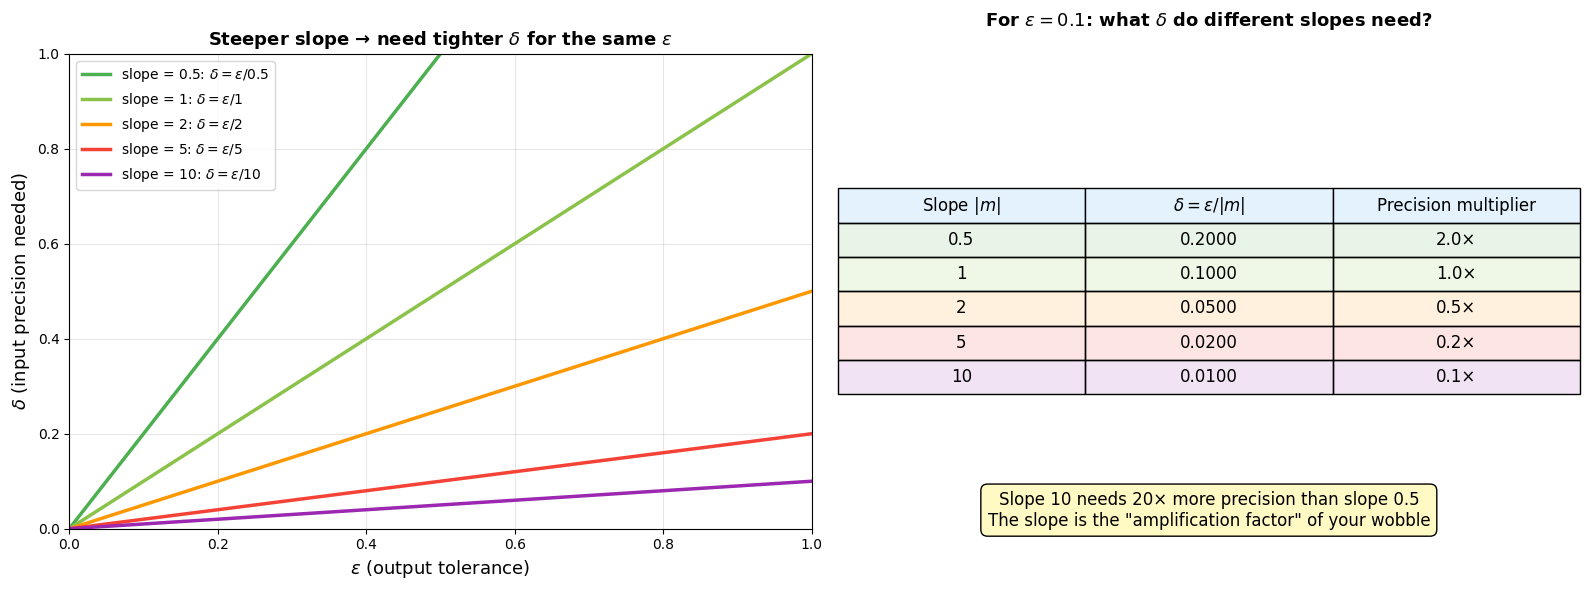

In [8]:
# === DIAGRAM 6: Delta vs Epsilon for different slopes — the exchange rate ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: delta as a function of epsilon for different slopes ---
eps_range = np.linspace(0.001, 1, 200)
slopes = [0.5, 1, 2, 5, 10]
slope_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336', '#9C27B0']

for m, col in zip(slopes, slope_colors):
    ax1.plot(eps_range, eps_range / m, '-', color=col, lw=2.5,
             label=f'slope = {m}: $\\delta = \\epsilon / {m}$')

ax1.set_xlabel('$\\epsilon$ (output tolerance)', fontsize=13)
ax1.set_ylabel('$\\delta$ (input precision needed)', fontsize=13)
ax1.set_title('Steeper slope → need tighter $\\delta$ for the same $\\epsilon$',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# --- RIGHT: Concrete example — table of values ---
ax2.axis('off')
ax2.set_title('For $\\epsilon = 0.1$: what $\\delta$ do different slopes need?',
              fontsize=13, fontweight='bold', pad=20)

table_data = []
for m in [0.5, 1, 2, 5, 10]:
    d = 0.1 / m
    table_data.append([f'{m}', f'{d:.4f}', f'{1/m:.1f}×'])

table = ax2.table(cellText=table_data,
                  colLabels=['Slope $|m|$', '$\\delta = \\epsilon / |m|$', 'Precision multiplier'],
                  cellLoc='center', loc='center',
                  colColours=['#E3F2FD', '#E3F2FD', '#E3F2FD'])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Color the rows
for i, col in enumerate(slope_colors):
    for j in range(3):
        table[i + 1, j].set_facecolor(col + '22')  # light version

ax2.text(0.5, 0.08,
         'Slope 10 needs 20× more precision than slope 0.5\n'
         'The slope is the "amplification factor" of your wobble',
         fontsize=12, ha='center', va='top', transform=ax2.transAxes,
         bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

## Step 7 — What About Curves? (The Nonlinear Case)

Everything above was for a straight line, where the slope is constant and life is simple. But what about $f(x) = x^2$?

The slope of $x^2$ isn't fixed — it changes at every point. Near $x = 1$ the slope is about $2$, near $x = 3$ it's about $6$. So the "exchange rate" depends on where I am.

Let me find $\delta$ for $\lim_{x \to 3} x^2 = 9$ with $\epsilon = 0.1$:

$$|x^2 - 9| < 0.1$$
$$|(x-3)(x+3)| < 0.1$$
$$|x - 3| \cdot |x + 3| < 0.1$$

If I stay close to $3$ (say $|x - 3| < 1$), then $x$ is between $2$ and $4$, so $|x + 3|$ is between $5$ and $7$ — at most $7$.

So $|x - 3| \cdot 7 < 0.1$ → $|x - 3| < 0.1/7 \approx 0.0143$.

I pick $\delta = \min(1, \; \epsilon/7)$. The $\min$ is just me being careful — I first restrict to a neighbourhood, then calculate the tightest bound.

The intuition is the same: near $x = 3$, $x^2$ has slope about $6$, so my output is roughly $6$ times as sensitive as my input. I need about $6\times$ more precision.

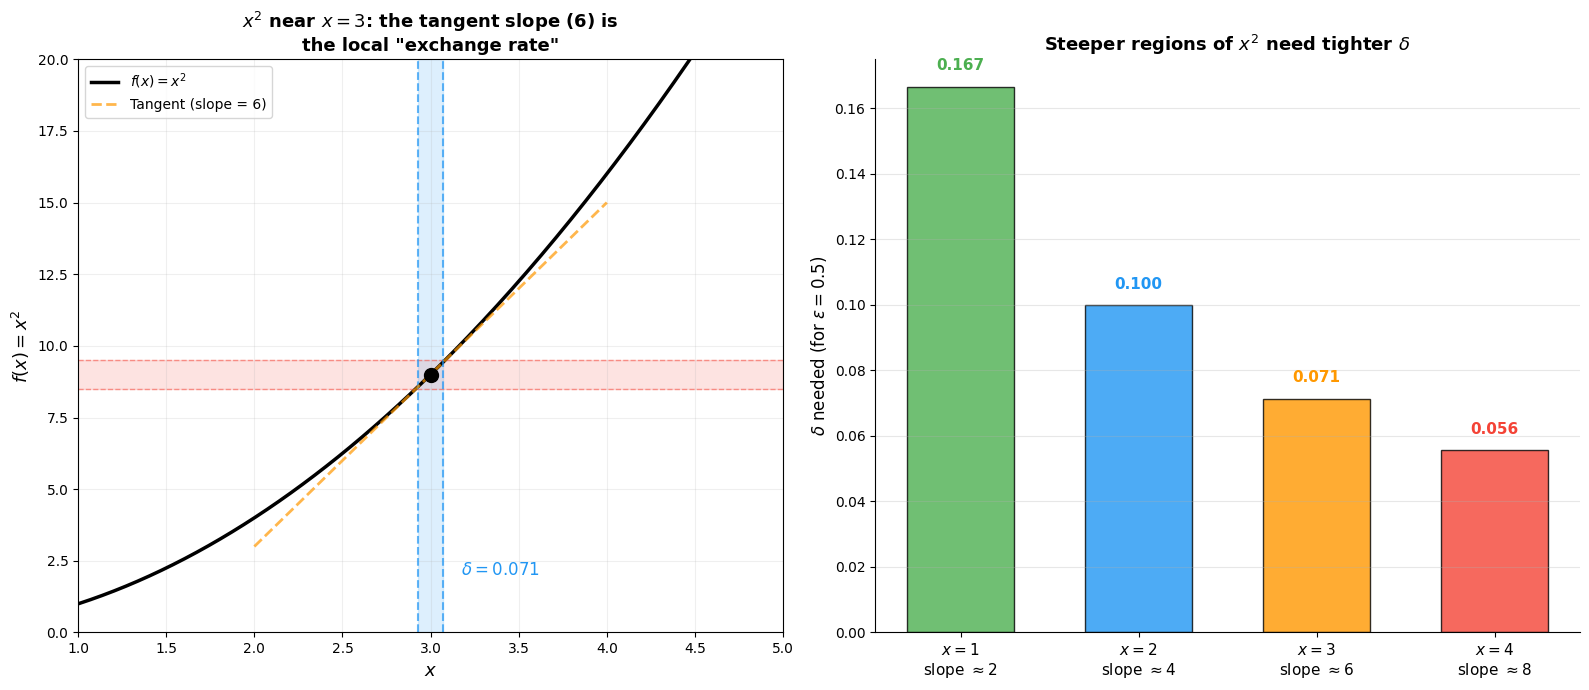

In [9]:
# === DIAGRAM 7: Nonlinear case — x² near x = 3 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

x = np.linspace(0, 5, 300)
f_vals = x**2

# --- LEFT: The parabola with epsilon-delta bands near x = 3 ---
eps = 0.5
# Near x = 3: |x+3| ≤ 7 (if |x-3| < 1), so delta = eps/7
delta = eps / 7

ax1.plot(x, f_vals, 'k-', lw=2.5, label='$f(x) = x^2$')
ax1.plot(3, 9, 'ko', ms=10, zorder=5)

# Epsilon band
ax1.fill_between(x, 9 - eps, 9 + eps, alpha=0.15, color='#F44336')
ax1.axhline(9 + eps, color='#F44336', ls='--', lw=1, alpha=0.5)
ax1.axhline(9 - eps, color='#F44336', ls='--', lw=1, alpha=0.5)

# Delta band
ax1.fill_betweenx([0, 25], 3 - delta, 3 + delta, alpha=0.15, color='#2196F3')
ax1.axvline(3 + delta, color='#2196F3', ls='--', lw=1.5, alpha=0.7)
ax1.axvline(3 - delta, color='#2196F3', ls='--', lw=1.5, alpha=0.7)

# Tangent line at x = 3 (slope = 6)
tang_x = np.linspace(2, 4, 50)
tang_y = 6 * (tang_x - 3) + 9
ax1.plot(tang_x, tang_y, '--', color='#FF9800', lw=2, alpha=0.7,
         label='Tangent (slope = 6)')

ax1.annotate(f'$\\epsilon = {eps}$', xy=(0.5, 9 + eps), fontsize=12,
             color='#F44336', fontweight='bold')
ax1.annotate(f'$\\delta = {delta:.3f}$', xy=(3 + delta + 0.1, 2), fontsize=12,
             color='#2196F3', fontweight='bold')

ax1.set_xlabel('$x$', fontsize=13)
ax1.set_ylabel('$f(x) = x^2$', fontsize=13)
ax1.set_title('$x^2$ near $x = 3$: the tangent slope (6) is\nthe local "exchange rate"',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(1, 5)
ax1.set_ylim(0, 20)
ax1.grid(True, alpha=0.2)

# --- RIGHT: Compare delta needed at different points on x² ---
points = [1, 2, 3, 4]
eps_fixed = 0.5
bar_colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

# At x = c: slope ≈ 2c, so delta ≈ eps / (2c + 1) approximately
# More precisely: |x² - c²| < eps → |x-c||x+c| < eps
# If |x-c| < 1, then |x+c| < 2c+1, so delta = eps/(2c+1)
deltas = [eps / (2 * c + 1) for c in points]
local_slopes = [2 * c for c in points]

x_pos = range(len(points))
bars = ax2.bar(x_pos, deltas, color=bar_colors, edgecolor='black', width=0.6, alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'$x = {c}$\nslope $\\approx {2*c}$' for c in points], fontsize=11)
ax2.set_ylabel(f'$\\delta$ needed (for $\\epsilon = {eps_fixed}$)', fontsize=12)
ax2.set_title('Steeper regions of $x^2$ need tighter $\\delta$',
              fontsize=13, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

# Value labels
for j, (d, col) in enumerate(zip(deltas, bar_colors)):
    ax2.text(j, d + 0.005, f'{d:.3f}', ha='center', fontsize=11,
             fontweight='bold', color=col)

plt.tight_layout()
plt.show()

## Step 8 — Numerical Verification: The Game In Action

Let me actually play the game. For each $\epsilon$ the critic throws at me, I'll compute my $\delta$ and verify that **every** $x$ inside my bubble lands inside theirs.

In [10]:
# === Numerical verification: playing the epsilon-delta game ===

print("The ε-δ Game for f(x) = 2x - 1, limit at x = 3, L = 5")
print("Slope = 2, so δ = ε / 2")
print("=" * 65)
print(f"{'ε (challenge)':>14} {'δ (response)':>14} {'x range':>20} {'f(x) range':>20}")
print("-" * 65)

for eps in [1.0, 0.5, 0.1, 0.01, 0.001, 0.0001]:
    delta = eps / 2
    x_lo, x_hi = 3 - delta, 3 + delta
    f_lo, f_hi = 2 * x_lo - 1, 2 * x_hi - 1
    print(f"{eps:>14.4f} {delta:>14.4f} ({x_lo:.5f}, {x_hi:.5f})  ({f_lo:.5f}, {f_hi:.5f})")

print("-" * 65)
print("\nEvery f(x) range fits inside (5 - ε, 5 + ε). I always win. ✓")

print("\n")
print("Now for f(x) = x², limit at x = 3, L = 9")
print("Using δ = min(1, ε/7) as our safe choice")
print("=" * 65)
print(f"{'ε (challenge)':>14} {'δ (response)':>14} {'x range':>20} {'f(x) range':>22}")
print("-" * 65)

for eps in [1.0, 0.5, 0.1, 0.01, 0.001]:
    delta = min(1, eps / 7)
    x_lo, x_hi = 3 - delta, 3 + delta
    f_lo, f_hi = x_lo**2, x_hi**2
    max_dev = max(abs(f_lo - 9), abs(f_hi - 9))
    ok = "✓" if max_dev < eps else "✗"
    print(f"{eps:>14.4f} {delta:>14.5f} ({x_lo:.5f}, {x_hi:.5f})  "
          f"({f_lo:.5f}, {f_hi:.5f})  {ok}")

print("-" * 65)
print("\nEvery f(x) range fits inside (9 - ε, 9 + ε). Game won again. ✓")

The ε-δ Game for f(x) = 2x - 1, limit at x = 3, L = 5
Slope = 2, so δ = ε / 2
 ε (challenge)   δ (response)              x range           f(x) range
-----------------------------------------------------------------
        1.0000         0.5000 (2.50000, 3.50000)  (4.00000, 6.00000)
        0.5000         0.2500 (2.75000, 3.25000)  (4.50000, 5.50000)
        0.1000         0.0500 (2.95000, 3.05000)  (4.90000, 5.10000)
        0.0100         0.0050 (2.99500, 3.00500)  (4.99000, 5.01000)
        0.0010         0.0005 (2.99950, 3.00050)  (4.99900, 5.00100)
        0.0001         0.0001 (2.99995, 3.00005)  (4.99990, 5.00010)
-----------------------------------------------------------------

Every f(x) range fits inside (5 - ε, 5 + ε). I always win. ✓


Now for f(x) = x², limit at x = 3, L = 9
Using δ = min(1, ε/7) as our safe choice
 ε (challenge)   δ (response)              x range             f(x) range
-----------------------------------------------------------------
        1.0000    

## The Bottom Line

Here's what I wish someone had told me from the start:

**A limit isn't about finding where a point is.** It's about proving **how close you can get** — and that you can get arbitrarily close.

The entire $\epsilon$-$\delta$ definition is a game:
1. A critic gives me an **output tolerance** ($\epsilon$) — how close do I need to be on the $y$-axis?
2. I compute an **input tolerance** ($\delta$) — how steady must my hand be on the $x$-axis?
3. The algebra **translates** between the two — it "undoes" the function to convert an output constraint into an input constraint
4. The **slope** is the exchange rate — it tells me how much the function amplifies my wobble
5. The **absolute value** makes it a bubble, not just a ceiling — closeness means closeness from *both* sides

My original mistake of writing $2x - 6 < 0.1$ wasn't wrong, it was just **half right**. The absolute value bars are there because limits care about closeness in every direction. The algebra is just the tool we use to calculate the tolerance of the universe.

Next time you see a $\delta$, don't see a variable — see a "steady hand" requirement. ✅